In [8]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np

#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

In [13]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

In [3]:
import seaborn as sns

In [12]:
scm.SHENDURE_BOUNDS

Bounds(metadata=None, min_mpra_umi=0.0034641979561541277, max_mpra_umi=369.88473782763344, by_cre_theta=0.62110305, by_cell_type_theta=0.35434753, by_cre_zi=rep_id
2B1    0.383713
2B2    0.410067
A1     0.440697
A2     0.414978
B1     0.365806
B2     0.358552
Name: by_cre_zi, dtype: float64, by_cell_type_zi=rep_id
2B1    0.019746
2B2    0.012776
A1     0.039399
A2     0.024900
B1     0.021129
B2     0.019881
Name: by_cell_type_zi, dtype: float64, num_cres=208, cells_per_cell_type=cell_type
Cardiomyocytes              680
EpiblastPrimitiveStreak    3445
ExEndodermParietal         4644
ExEndodermVisceral         3238
Haematoendothelial         1079
Mesoderm                   7427
NeuroectodermBrain         7750
NeuroectodermRostral       1757
SurfaceEctoderm            5168
reference                  8201
Name: cells_per_cell_type, dtype: int64, transfection_nb_mu=18.010555670792133, transfection_nb_alpha=0.5705626300443596)

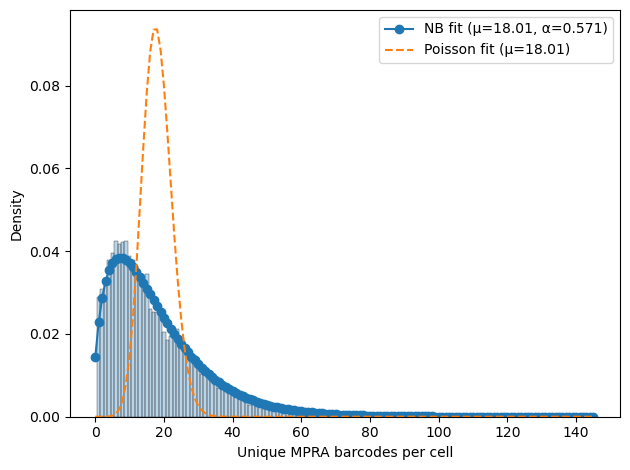

{'poisson_mu': 18.01055567079212,
 'nb_mu': 18.010555670792133,
 'nb_alpha': 0.5705626300443596}

In [15]:
primordial.training_data.describe_transfection(True)

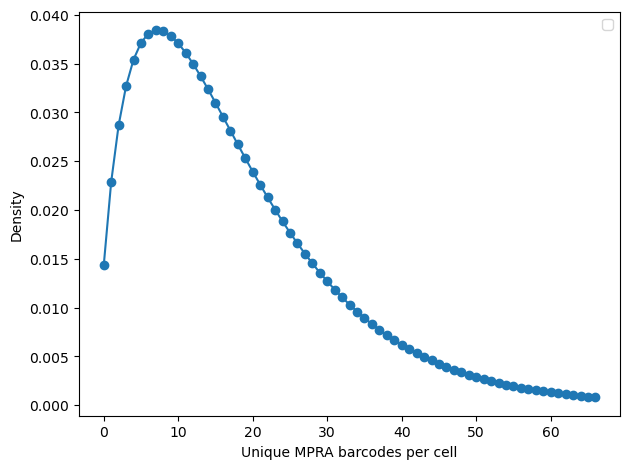

In [17]:
scm.SHENDURE_BOUNDS.plot_transfection()

Here's an example of creating an artificial experiment.

In [19]:
artificial_bounds=scm.SHENDURE_BOUNDS.copy()
artificial_bounds.get_effective_moi()

18.010555670792133

In [22]:
artificial_bounds.set_effective_moi(100)

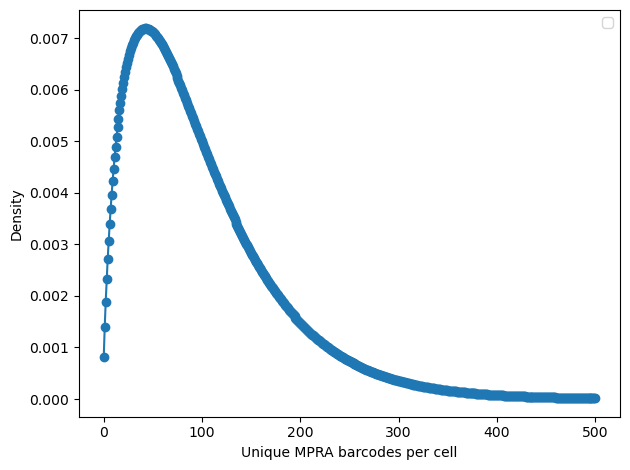

In [23]:
artificial_bounds.plot_transfection()

In [ ]:
#We first define our 
xyz=shendure_bounds.copy()

AttributeError: 'Bounds' object has no attribute 'copy'

In [ ]:
def change_MOI():
    pass


def simple_spread():
    """
    Called on a bounds object. Pass 
    """
    pass

In [ ]:
def description_from_bounds(inp:scm.Bounds,
                            type="simple_spread",
                            nb_override=None):
    """
    Returns a primordial description dask dataframe

    and a hypothesis set describing the (unimplemented)
    
    Only type implemented for now is `simple_spread`
    - tiles CREs over the bounds range 
    other will be 
    - `override` : allowing you to specify exactly what nb param
    """

    #known before you start or "to be optimized":
    #  cells per cell-type is a fixed parameter
    #  barcodes per CRE is a fixed parameter
    
    #for each cell type, cell, decide how many MPRA barcodes are transfected.
    #note that MOI here is measured, not applied MOI. Transfection inefficiencies
    #Will effectively reduce MOI from what is applied. 
    #probably the way to do it is
    # - calculate fraction of cells with 0, 1, 2, 3... barcodes
    # - multiple fractions by total number of cells & round
    # - make a table with n=total_cells cell barcodes
    # - add number of barcodes in each cell as a column according to fraction (n_transfected).
    # - randomize row order
    # - assign cell_type based on proportions
    # - randomly sample n_transfected MPRA barcodes for each row, then convert to tall
    # - merge in CRE identity 

    #for a non-tfection reporter setup, extend to 'all-by-all' (all mpra BC by all ) filling in zeroes

    #The output will look like a describe_primordial description dataframe. 
    pass

desired_moi=20



In [ ]:
xyz.training_data.data

In [ ]:
b=from_ortho(xyz)

In [ ]:
b

In [ ]:
dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_v3.tsv")
dat.ortho_filter()
dat.set_negative_controls(["nobody","weak"])
dat.set_reference_cell("liver")
primordial=scm.ortho()
primordial.criss_cross(client,dat=dat)
primordial.extract_params(client)

In [ ]:
primordial.save(".","test_save")

In [ ]:
xyz.training_data.data["umis_mpra_bc"]

In [5]:
cluster.close()